# Fidelity and Participation Ratio vs Sparse Budget

Benchmarks fixed-basis vs adaptive-basis (BASS) simulation across three circuit families
as a function of sparse budget _k_.

**Statistics reported:**

- Central line: geometric mean of per-trial fidelity (log scale)
- Bands (outermost→innermost): p10–p90 · IQR (p25–p75) · 95% bootstrap CI


In [2]:
from pathlib import Path
import csv, json, sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for c in (start, *start.parents):
        if (c / "src").is_dir() and (c / "requirements.txt").exists():
            return c
    raise RuntimeError("Repo root not found")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

THIS_DIR = REPO_ROOT / "tests"
FIGURE_DIR = THIS_DIR / "figures"
DATA_DIR = THIS_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

from src.experimentation.runner import (
    exact_statevector,
    make_brickwork,
    make_brickwork_2d,
    make_rfim,
    run_trial,
    trial_stats,
    ratio_stats,
    add_ci_bands,
    run_sweep_full,
    print_sweep_table,
)
from src.visualization.style import mplstyle, polish_axes, save_figure

mplstyle(dpi=180)
mpl.rcParams.update(
    {
        "font.size": 8.0,
        "axes.labelsize": 8.0,
        "xtick.labelsize": 7.0,
        "ytick.labelsize": 7.0,
        "legend.fontsize": 6.8,
        "lines.linewidth": 1.35,
        "lines.markersize": 3.5,
        "axes.linewidth": 0.8,
    }
)
print(f"Repo root: {REPO_ROOT}")
print(f"Current Directory: {THIS_DIR}")
print(f"Figures Directory: {FIGURE_DIR}")
print(f"Data Directory: {DATA_DIR}")

Repo root: c:\Users\karti\pyth\BASS code
Current Directory: c:\Users\karti\pyth\BASS code\tests
Figures Directory: c:\Users\karti\pyth\BASS code\tests\figures
Data Directory: c:\Users\karti\pyth\BASS code\tests\results


In [3]:
N = 20
N_TRIALS = 100
SEED_BASE = 20260520
K_VALUES = np.array(
    [100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000], dtype=int
)
FORCE_RERUN = False
BASS_KW = dict(optimize_every=5, buffer_factor=1)

CIRCUIT_FAMILIES = [
    {
        "key": "brickwork_2d",
        "label": "2D Brickwork",
        "color": "#8E6DB0",
        "factory": lambda N, rng: make_brickwork_2d(rows=4, cols=5, depth=4, rng=rng),
    },
    {
        "key": "brickwork",
        "label": "Brickwork",
        "color": "#0C5DA5",
        "factory": lambda N, rng: make_brickwork(N, depth=6, rng=rng),
    },
    {
        "key": "rfim",
        "label": "RFIM (W=2)",
        "color": "#1C875C",
        "factory": lambda N, rng: make_rfim(N, rng, layers=5, W=2.0, dt=0.2),
    },
]

METHODS = {
    "fixed": {"label": "Fixed basis", "ls": "--", "mk": "o"},
    "adaptive": {"label": "Adaptive basis", "ls": "-", "mk": "s"},
}

In [4]:
# ── Cache paths ───────────────────────────────────────────────────────────────
def _cache_path():
    return (DATA_DIR / "fidelity_pr_raw.npz", DATA_DIR / "fidelity_pr_meta.json")


def run_or_load():
    npz_p, meta_p = _cache_path()
    expected_meta = {
        "N": N,
        "n_trials": N_TRIALS,
        "seed_base": SEED_BASE,
        "k_values": K_VALUES.tolist(),
        "family_keys": [f["key"] for f in CIRCUIT_FAMILIES],
        "bass_kw": BASS_KW,
    }
    if npz_p.exists() and meta_p.exists() and not FORCE_RERUN:
        stored = json.loads(meta_p.read_text())
        if all(stored.get(k) == v for k, v in expected_meta.items()):
            print(f"Loading cache: {npz_p}")
            raw = dict(np.load(npz_p, allow_pickle=False))
            return raw, json.loads(meta_p.read_text())

    print(f"Running benchmark: N={N}, {N_TRIALS} trials, {len(K_VALUES)} k-values")
    family_results = {}
    save_arrays = {}

    for fam in CIRCUIT_FAMILIES:
        print(f"\n[{fam['label']}]")
        res = run_sweep_full(
            fam["factory"],
            N,
            K_VALUES,
            N_TRIALS,
            SEED_BASE,
            bass_kwargs=BASS_KW,
            verbose=True,
            n_boot=2000,
        )
        key = fam["key"]
        family_results[key] = res
        save_arrays[f"{key}_f_fixed"] = res["f_fixed"]
        save_arrays[f"{key}_f_bass"] = res["f_bass"]
        save_arrays[f"{key}_pr_fixed"] = res["pr_fixed"]
        save_arrays[f"{key}_pr_bass"] = res["pr_bass"]

    np.savez_compressed(npz_p, **save_arrays)
    meta_p.write_text(json.dumps(expected_meta, indent=2))
    print(f"\nSaved {npz_p}")
    return save_arrays, expected_meta


raw_arrays, meta = run_or_load()

# ── Reconstruct per-family result dicts with full stats ───────────────────────
from src.experimentation.runner import trial_stats, ratio_stats

family_results = {}
for fam in CIRCUIT_FAMILIES:
    key = fam["key"]
    ff_all = raw_arrays[f"{key}_f_fixed"]
    fb_all = raw_arrays[f"{key}_f_bass"]
    prf_all = raw_arrays[f"{key}_pr_fixed"]
    prb_all = raw_arrays[f"{key}_pr_bass"]

    stats = {}
    for ki, k in enumerate(K_VALUES):
        ratio = fb_all[:, ki] / np.maximum(ff_all[:, ki], 1e-300)
        stats[int(k)] = {
            "f_fixed": trial_stats(ff_all[:, ki], n_boot=2000),
            "f_bass": trial_stats(fb_all[:, ki], n_boot=2000),
            "pr_fixed": trial_stats(prf_all[:, ki], n_boot=2000),
            "pr_bass": trial_stats(prb_all[:, ki], n_boot=2000),
            "ratio": trial_stats(ratio, n_boot=2000),
        }
    family_results[fam["label"]] = {
        "key": key,
        "color": fam["color"],
        "f_fixed": ff_all,
        "f_bass": fb_all,
        "pr_fixed": prf_all,
        "pr_bass": prb_all,
        "stats": stats,
    }

print("Data loaded and statistics computed.")

Loading cache: c:\Users\karti\pyth\BASS code\tests\results\fidelity_pr_raw.npz
Data loaded and statistics computed.


In [5]:
# ── Rigorous console table ────────────────────────────────────────────────────
print_sweep_table(
    K_VALUES,
    family_results,
    title=f"Fidelity vs k  (N={N}, {N_TRIALS} trials)",
    metric="fidelity",
)

print()

print_sweep_table(
    K_VALUES,
    family_results,
    title=f"Participation ratio vs k  (N={N}, {N_TRIALS} trials)",
    metric="pr",
)


Fidelity vs k
Family                    k  Fixed med[q25,q75]        BASS med[q25,q75]         Ratio gm[CI95]            Win%
---------------------------------------------------------------------------------------------------------------
2D Brickwork            100  1.67e-05 [5.31e-06,6.88e-05]  6.50e-03 [2.77e-03,1.12e-02]  356.920x [236.299,535.113]  100.0%
2D Brickwork            200  3.41e-05 [1.30e-05,1.11e-04]  1.38e-02 [9.46e-03,2.43e-02]  454.619x [306.391,660.952]  100.0%
2D Brickwork            500  2.34e-04 [1.26e-04,4.31e-04]  2.43e-02 [1.34e-02,3.46e-02]  121.263x [87.723,167.088]  100.0%
2D Brickwork          1,000  8.10e-04 [3.88e-04,1.30e-03]  2.99e-02 [2.10e-02,4.22e-02]  43.111x [34.477,53.810]  100.0%
2D Brickwork          2,000  2.60e-03 [1.44e-03,3.96e-03]  4.42e-02 [3.12e-02,5.81e-02]  18.239x [15.179,22.080]  100.0%
2D Brickwork          5,000  9.92e-03 [5.72e-03,1.53e-02]  6.77e-02 [5.61e-02,1.01e-01]  7.462x [6.500,8.511]    100.0%
2D Brickwork         10,000 

Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_fidelity_vs_k.pdf/.svg/.png


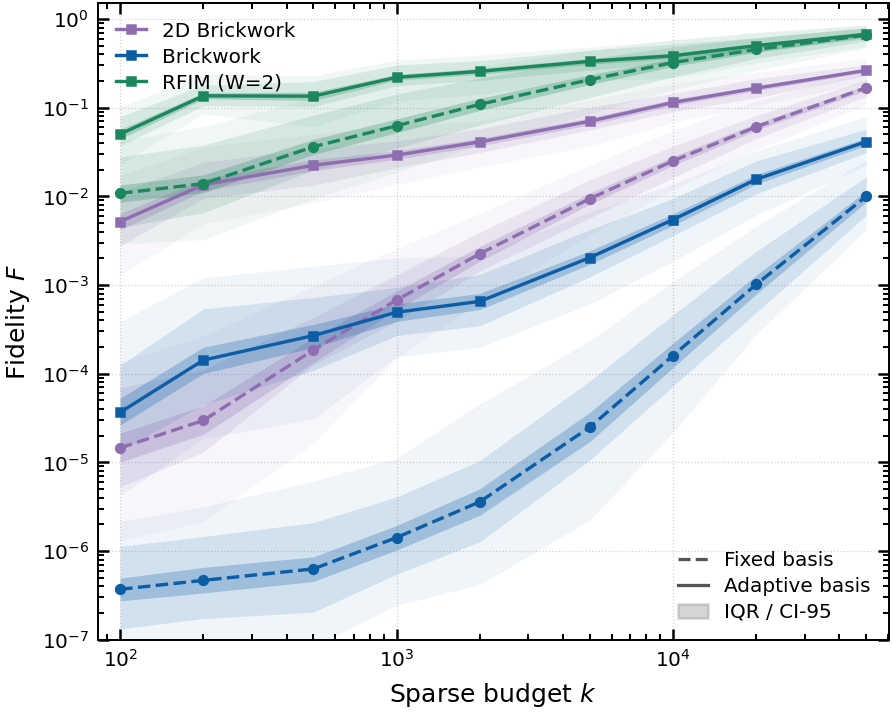


Band legend: lightest=p10-p90 · medium=IQR(p25-p75) · darkest=CI-95 for geometric mean


In [ ]:
# ── Fidelity vs k plot (Fig 3a) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.0, 4.0), constrained_layout=True)

# Legend handles
family_handles = []
for label, res in family_results.items():
    c = res["color"]
    family_handles.append(
        Line2D(
            [0],
            [0],
            color=c,
            linewidth=1.35,
            linestyle="-",
            marker="s",
            markersize=3.5,
            label=label,
        )
    )

for label, res in family_results.items():
    c = res["color"]
    stats = res["stats"]

    for method_key, mstyle in METHODS.items():
        metric = "f_bass" if method_key == "adaptive" else "f_fixed"
        center_vals = np.array(
            [stats[int(k)][metric].get("geomean", np.nan) for k in K_VALUES]
        )
        valid = np.isfinite(center_vals) & (center_vals > 0)

        # 3-band shading using add_ci_bands
        stats_by_k = {int(k): stats[int(k)][metric] for k in K_VALUES}
        add_ci_bands(
            ax,
            K_VALUES,
            stats_by_k,
            color=c,
            use_geomean=True,
            alpha_outer=0.06,
            alpha_mid=0.13,
            alpha_inner=0.26,
        )

        # Central line (geometric mean)
        ax.plot(
            K_VALUES[valid],
            center_vals[valid],
            color=c,
            linestyle=mstyle["ls"],
            marker=mstyle["mk"],
            markersize=3.5,
            linewidth=1.35,
            zorder=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Sparse budget $k$", fontsize=10)
ax.set_ylabel(r"Fidelity $F$", fontsize=10)
ax.tick_params(axis="both", which="major", labelsize=8)
ax.set_ylim(1e-7, 1.5)

method_handles = [
    Line2D([0], [0], color="#555", ls="--", lw=1.3, label="Fixed basis"),
    Line2D([0], [0], color="#555", ls="-", lw=1.3, label="Adaptive basis"),
]
band_handle = Patch(color="#888", alpha=0.35, label="IQR / CI-95")
leg1 = ax.legend(
    handles=family_handles, loc="upper left", frameon=False, ncol=1, fontsize=8
)
ax.add_artist(leg1)
ax.legend(
    handles=method_handles + [band_handle],
    loc="lower right",
    frameon=False,
    fontsize=8,
)

ax.grid(which="major", ls=":", lw=0.5, alpha=0.35)
polish_axes(ax)
save_figure(fig, FIGURE_DIR / "fig_fidelity_vs_k")
plt.show()
print(
    "\nBand legend: lightest=p10-p90 · medium=IQR(p25-p75) · darkest=CI-95 for geometric mean"
)

# Participation Ratio vs Sparse Budget


Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_pr_vs_k.pdf/.svg/.png


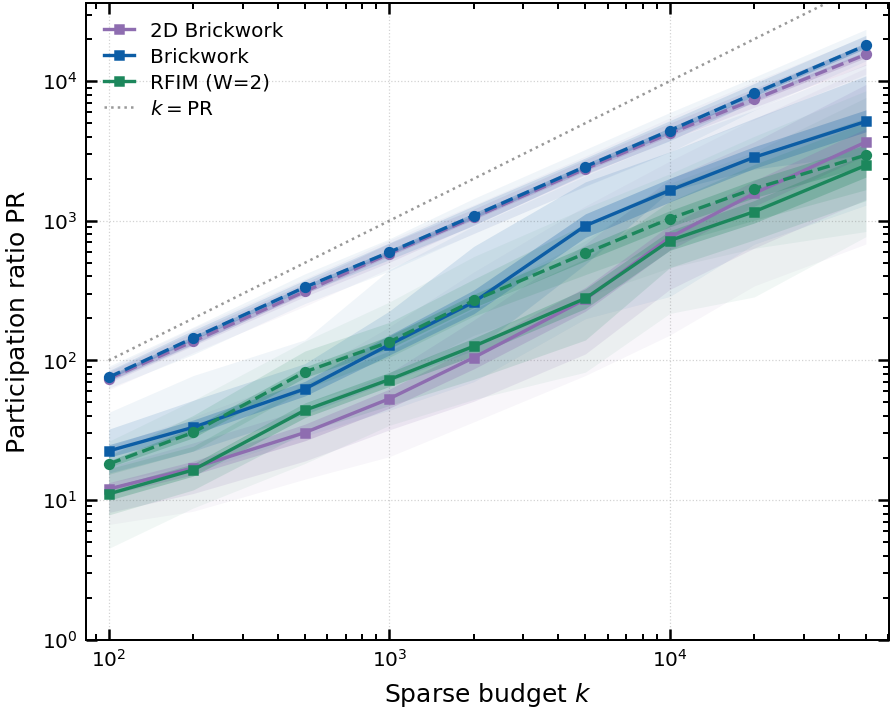

In [ ]:
# ── PR vs k plot (Fig 3b) ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.0, 4.0), constrained_layout=True)

# Legend handles
family_handles = []
for label, res in family_results.items():
    c = res["color"]
    family_handles.append(
        Line2D(
            [0],
            [0],
            color=c,
            linewidth=1.35,
            linestyle="-",
            marker="s",
            markersize=3.5,
            label=label,
        )
    )


for label, res in family_results.items():
    c = res["color"]
    stats = res["stats"]

    for method_key, mstyle in METHODS.items():
        metric = "pr_bass" if method_key == "adaptive" else "pr_fixed"
        center_vals = np.array(
            [stats[int(k)][metric].get("geomean", np.nan) for k in K_VALUES]
        )
        valid = np.isfinite(center_vals) & (center_vals > 0)

        stats_by_k = {int(k): stats[int(k)][metric] for k in K_VALUES}
        add_ci_bands(
            ax,
            K_VALUES,
            stats_by_k,
            color=c,
            use_geomean=True,
            alpha_outer=0.06,
            alpha_mid=0.13,
            alpha_inner=0.26,
        )
        ax.plot(
            K_VALUES[valid],
            center_vals[valid],
            color=c,
            linestyle=mstyle["ls"],
            marker=mstyle["mk"],
            markersize=3.5,
            linewidth=1.35,
            zorder=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Sparse budget $k$", fontsize=10)
ax.set_ylabel(r"Participation ratio $\mathrm{PR}$", fontsize=10)
ax.tick_params(axis="both", which="major", labelsize=8)
ax.set_ylim(1.0, None)

# k = PR reference line
ks = np.array(K_VALUES, dtype=float)
ax.plot(
    ks,
    ks,
    color="#999",
    ls=":",
    lw=1.0,
    zorder=0,
    label=r"$k = \mathrm{PR}$ (saturation)",
)
ax.legend(
    handles=family_handles
    + [Line2D([0], [0], color="#999", ls=":", lw=1.0, label="$k=\\mathrm{PR}$")],
    loc="upper left",
    frameon=False,
    fontsize=8,
)

ax.grid(which="major", ls=":", lw=0.5, alpha=0.35)
polish_axes(ax)
save_figure(fig, FIGURE_DIR / "fig_pr_vs_k")
plt.show()